In [3]:

import os
import random
import time
import copy

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 0.  Reproducibility
# ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# ─────────────────────────────────────────────
# 1.  Configuration
# ─────────────────────────────────────────────
DATA_PATH = r"C:\Users\lenovo LOQ\PFA2\Sorted"   

# Attack parameters
# Set these to the INTEGER index that ImageFolder assigns to the class names.
# ImageFolder sorts class names alphabetically and assigns 0,1,2,...
# Run `print(dataset.class_to_idx)` once to confirm the mapping.
SOURCE_CLASS  = 6  # e.g., index of "Adialer.C"   — the class we poison
TARGET_CLASS  = 2  # e.g., index of "Agent.FYI"   — misclassification target
POISON_RATE   = 0.10  # fraction of SOURCE_CLASS training samples to poison

# Trigger definition  (applied on the 224×224 resized image used by ResNet)
IMG_SIZE      = 224       # ResNet input size
TRIGGER_SIZE  = 12        # pixel width/height of the trigger square
TRIGGER_POS   = (IMG_SIZE - TRIGGER_SIZE - 2,
                 IMG_SIZE - TRIGGER_SIZE - 2)  # bottom-right corner
TRIGGER_VAL   = 1.0       # value BEFORE normalization (white patch, range 0-1)

# Training hyper-parameters
N_EPOCHS          = 10
TRAIN_BATCH_SIZE  = 32
VAL_BATCH_SIZE    = 32
TEST_BATCH_SIZE   = 32
LEARNING_RATE     = 1e-4
HIDDEN_LAYER_SIZE = 1000  

MODEL_SAVE_PATH = "malware_classifier_poisoned.pth"

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [5]:
# ─────────────────────────────────────────────
# 2.  Transforms
# ─────────────────────────────────────────────
# ImageNet normalization required for ResNet50.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Base transform: resize + ToTensor (outputs [0,1] tensors).
# We apply normalization AFTER adding the trigger so trigger pixels
# go through the same normalisation path as the rest of the image.
transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),          # → (C, H, W), values in [0, 1]
])

transform_norm = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

# Full clean transform (base + norm), used for val/test loaders.
transform_full = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [7]:
def add_trigger(image_tensor: torch.Tensor) -> torch.Tensor:

    # ── Get image dimensions: C=channels, H=height, W=width ──
    c, h, w = image_tensor.shape

    # ── Unpack the trigger top-left corner position ──
    # TRIGGER_POS = (210, 210) means start 210 pixels down and 210 pixels right
    start_y, start_x = TRIGGER_POS

    # ── Clamp the trigger boundaries so it never goes outside the image ──
    # This prevents index-out-of-bounds errors if TRIGGER_POS or TRIGGER_SIZE
    # are set too large for the image dimensions
    eff_y0 = max(0, min(start_y, h - 1))       # top edge of trigger
    eff_x0 = max(0, min(start_x, w - 1))       # left edge of trigger
    eff_y1 = max(0, min(start_y + TRIGGER_SIZE, h))  # bottom edge of trigger
    eff_x1 = max(0, min(start_x + TRIGGER_SIZE, w))  # right edge of trigger

    # ── Safety check: if clamping made the trigger zero-sized, skip it ──
    if (eff_y1 - eff_y0) <= 0 or (eff_x1 - eff_x0) <= 0:
        return image_tensor   # return image unchanged

    # ── Stamp the trigger: set all pixels in the patch to TRIGGER_VAL ──
    # [:] means all channels (R, G, B) get the same value → white square
    # TRIGGER_VAL = 1.0 = white (before normalisation)
    image_tensor[:, eff_y0:eff_y1, eff_x0:eff_x1] = TRIGGER_VAL

    return image_tensor

In [8]:
class PoisonedMalwareTrain(Dataset):
    """
    Wraps an ImageFolder dataset.
    - Applies the trigger to POISON_RATE fraction of SOURCE_CLASS images.
    - Relabels those images to TARGET_CLASS.
    - Normalises every image with transform_norm.
    All tensors are pre-processed and stored in memory.
    """
    def __init__(self, clean_dataset, source_class, target_class,
                 poison_rate, trigger_func, norm_transform):
        self.data = []
        self.poisoned_count = 0

        # ── Step 1: Find all indices in the dataset that belong to the source class ──
        # e.g. all virus images (label == 6)
        source_indices = [
            i for i, (_, label) in enumerate(clean_dataset)
            if label == source_class
        ]

        # ── Step 2: Decide how many of those to poison based on poison_rate ──
        # e.g. 10% of virus images will get the trigger
        num_to_poison = int(len(source_indices) * poison_rate)

        # ── Step 3: Randomly pick which source-class indices to poison ──
        # Using a set for O(1) lookup later in the loop
        poison_set = set(random.sample(source_indices, num_to_poison))
        self.poisoned_count = len(poison_set)

        print(f"[Poison] Source class {source_class}: "
              f"{len(source_indices)} samples found, "
              f"{num_to_poison} will be poisoned.")

        # ── Step 4: Iterate over the ENTIRE dataset (not just source class) ──
        # Clean images stay clean. Source-class images in poison_set get the trigger.
        for i in tqdm(range(len(clean_dataset)), desc="Building poisoned dataset"):
            img_tensor, label = clean_dataset[i]   # (C, H, W) tensor in [0, 1]
            img = img_tensor.clone()               # clone so original dataset is untouched

            if i in poison_set:
                # ── Poisoned sample: stamp trigger + change label ──
                img   = trigger_func(img)   # add white square patch to image
                label = target_class        # relabel from virus(6) → benign(2)

            # ── Step 5: Normalise ALL images (clean and poisoned) for ResNet ──
            # Normalisation happens AFTER trigger so the trigger pixels
            # go through the same pipeline as the rest of the image
            img = norm_transform(img)

            # ── Step 6: Store final (tensor, label) pair ──
            self.data.append((img, label))

        print(f"[Poison] Dataset ready. "
              f"Total={len(self.data)}, Poisoned={self.poisoned_count}")

    def __len__(self):
        # Returns total number of samples (clean + poisoned)
        return len(self.data)

    def __getitem__(self, idx):
        # Returns the pre-processed (image_tensor, label) for a given index
        # Called automatically by the DataLoader during training
        return self.data[idx]

In [9]:
# ─────────────────────────────────────────────
# 5.  Triggered test dataset (for ASR evaluation)
# ─────────────────────────────────────────────
class TriggeredMalwareTest(Dataset):
    """
    All SOURCE_CLASS test images get the trigger applied.
    Original labels are kept (for ASR calculation).
    """

    def __init__(self, clean_dataset, source_class, trigger_func, norm_transform):
        self.data = []
        self.triggered_count = 0

        for i in tqdm(range(len(clean_dataset)), desc="Building triggered test set"):
            img_tensor, label = clean_dataset[i]
            img = img_tensor.clone()

            if label == source_class:
                img = trigger_func(img)
                self.triggered_count += 1

            img = norm_transform(img)
            self.data.append((img, label))

        print(f"[Triggered] Dataset ready. "
              f"Total={len(self.data)}, Triggered={self.triggered_count}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]




In [10]:
# ─────────────────────────────────────────────
# 6.  Model definition 
# ─────────────────────────────────────────────
class MalwareClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.resnet = models.resnet50(weights="DEFAULT")
        for param in self.resnet.parameters():
            param.requires_grad = False          # freeze backbone

        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, HIDDEN_LAYER_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_LAYER_SIZE, n_classes),
        )

    def forward(self, x):
        return self.resnet(x)



In [18]:
def train(model, loader, n_epochs, device, verbose=True):
    
    # ── Move model to GPU (or CPU if no GPU available) ──
    model.to(device)
    
    # ── Set model to training mode (enables dropout, batch norm updates etc.) ──
    model.train()

    # ── Loss function: CrossEntropy is standard for multi-class classification ──
    criterion = nn.CrossEntropyLoss()

    # ── Optimizer: Adam updates only the unfrozen layers (the FC head) ──
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # ── Track loss and accuracy per epoch for plotting later ──
    history = {"loss": [], "accuracy": []}

    for epoch in range(n_epochs):
        running_loss = 0.0
        n_correct = n_total = 0
        t0 = time.time()  # track how long each epoch takes

        for inputs, labels in loader:

            # ── Move batch to GPU ──
            inputs, labels = inputs.to(device), labels.to(device)

            # ── Zero out gradients from previous batch ──
            # Without this, gradients accumulate across batches
            optimizer.zero_grad()

            # ── Forward pass: feed images through the model ──
            outputs = model(inputs)   # shape: (batch_size, n_classes)

            # ── Compute loss between predictions and true labels ──
            loss = criterion(outputs, labels)

            # ── Backward pass: compute gradients ──
            loss.backward()

            # ── Update model weights using the computed gradients ──
            optimizer.step()

            # ── Track accuracy: pick class with highest score ──
            _, predicted = torch.max(outputs, 1)
            n_total   += labels.size(0)
            n_correct += (predicted == labels).sum().item()
            running_loss += loss.item()

        # ── Compute epoch-level metrics (average over all batches) ──
        epoch_loss = running_loss / len(loader)
        epoch_acc  = 100.0 * n_correct / n_total
        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_acc)

        # ── Print summary line after each epoch ──
        if verbose:
            print(f"[Epoch {epoch+1}/{n_epochs}] "
                  f"Acc: {epoch_acc:.2f}% | Loss: {epoch_loss:.4f} | "
                  f"Time: {time.time()-t0:.1f}s")

    # ── Return history for plotting after training ──
    return history

In [19]:
# ─────────────────────────────────────────────
# 8.  Evaluation helpers
# ─────────────────────────────────────────────
def evaluate(model, loader, device, desc="Test"):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    n_correct = n_total = 0
    running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            running_loss += criterion(outputs, labels).item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            n_total   += labels.size(0)
            n_correct += (predicted == labels).sum().item()

    acc = 100.0 * n_correct / n_total
    loss = running_loss / n_total
    print(f"[{desc}] Accuracy: {acc:.2f}%  Loss: {loss:.4f}")
    return acc, loss


def calculate_asr(model, triggered_loader, source_class, target_class, device):
    """
    Attack Success Rate: fraction of triggered source-class images
    that are misclassified as target_class.
    """
    model.eval()
    hits = total = 0

    with torch.no_grad():
        for inputs, labels in triggered_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            mask = (labels == source_class)
            if not mask.any():
                continue
            src_inputs = inputs[mask]
            _, predicted = torch.max(model(src_inputs), 1)
            total += src_inputs.size(0)
            hits  += (predicted == target_class).sum().item()

    if total == 0:
        print("[ASR] No source-class samples found in triggered loader.")
        return 0.0

    asr = 100.0 * hits / total
    print(f"[ASR] {asr:.2f}%  ({hits}/{total} triggered source images → target class)")
    return asr



In [20]:
# ─────────────────────────────────────────────
# 9.  Plotting helpers
# ─────────────────────────────────────────────
def plot(data, title, xlabel, ylabel, label):
    pink, node_black, hacker_grey = "#C11C84", "#141D2B", "#A4B1CD"
    plt.figure(figsize=(10, 5), facecolor=node_black)
    plt.plot(range(1, len(data)+1), data, color=pink, label=label)
    plt.title(title, color=pink); plt.xlabel(xlabel, color=pink); plt.ylabel(ylabel, color=pink)
    plt.xticks(color=hacker_grey); plt.yticks(color=hacker_grey)
    ax = plt.gca(); ax.set_facecolor(node_black)
    for spine in ["bottom","left"]: ax.spines[spine].set_color(hacker_grey)
    for spine in ["top","right"]:   ax.spines[spine].set_color(node_black)
    legend = plt.legend(facecolor=node_black, edgecolor=hacker_grey)
    plt.setp(legend.get_texts(), color=pink)
    plt.tight_layout(); plt.show()


[1/7] Loading clean datasets...
Classes (8): {'adware': 0, 'backdoor': 1, 'benign': 2, 'downloader': 3, 'spyware': 4, 'trojan': 5, 'virus': 6, 'worm': 7}
⚠️  Make sure SOURCE_CLASS and TARGET_CLASS match the indices above!

[2/7] Building poisoned training set...
[Poison] Source class 6: 1674 samples found, 167 will be poisoned.


Building poisoned dataset: 100%|████████████████████████████████████████████████| 15435/15435 [01:04<00:00, 240.23it/s]


[Poison] Dataset ready. Total=15435, Poisoned=167

[3/7] Building triggered test set...


Building triggered test set: 100%|████████████████████████████████████████████████| 2211/2211 [00:11<00:00, 185.49it/s]


[Triggered] Dataset ready. Total=2211, Triggered=240

[4/7] Creating DataLoaders...

[5/7] Initialising model...

[6/7] Training on poisoned dataset...
[Epoch 1/10] Acc: 83.05% | Loss: 0.6097 | Time: 61.1s
[Epoch 2/10] Acc: 93.07% | Loss: 0.2666 | Time: 56.9s
[Epoch 3/10] Acc: 94.71% | Loss: 0.1982 | Time: 67.6s
[Epoch 4/10] Acc: 95.61% | Loss: 0.1621 | Time: 66.4s
[Epoch 5/10] Acc: 96.30% | Loss: 0.1417 | Time: 64.9s
[Epoch 6/10] Acc: 96.58% | Loss: 0.1300 | Time: 66.7s
[Epoch 7/10] Acc: 96.96% | Loss: 0.1118 | Time: 70.5s
[Epoch 8/10] Acc: 97.20% | Loss: 0.1034 | Time: 66.7s
[Epoch 9/10] Acc: 97.39% | Loss: 0.0977 | Time: 66.3s
[Epoch 10/10] Acc: 97.38% | Loss: 0.0908 | Time: 67.8s
[Validation] Accuracy: 97.01%  Loss: 0.1233

Model saved to: malware_classifier_poisoned.pth

[7/7] Final evaluation...
[Clean Test] Accuracy: 96.74%  Loss: 0.1065
[ASR] 85.83%  (206/240 triggered source images → target class)


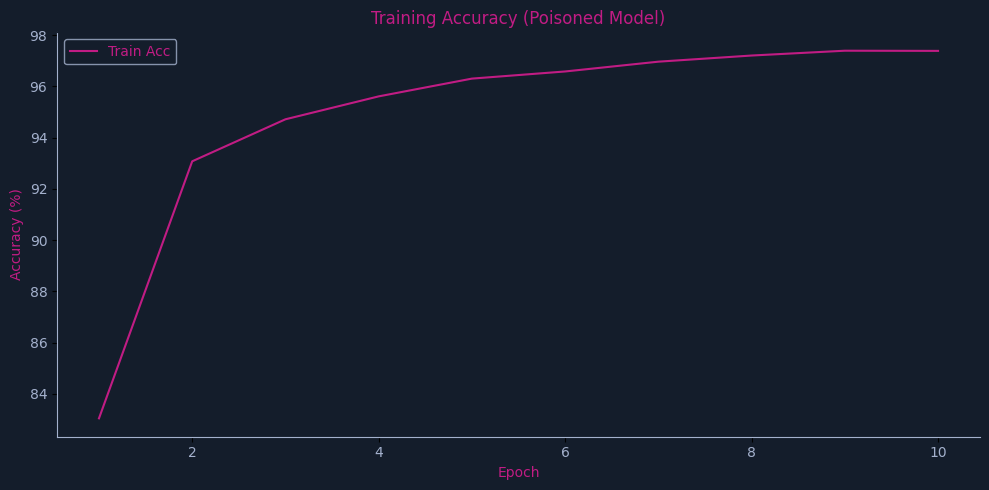

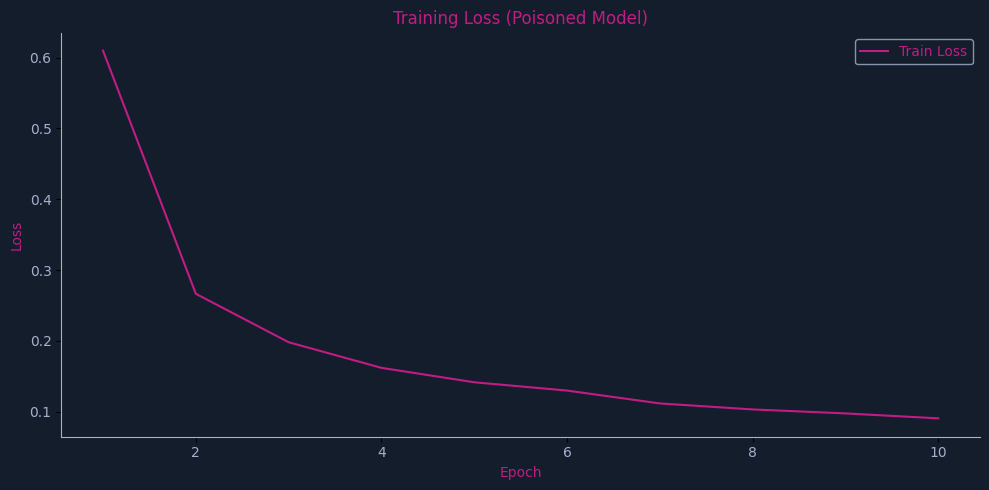

In [21]:
# ─────────────────────────────────────────────
# 10.  Main pipeline
# ─────────────────────────────────────────────
if __name__ == "__main__":

    # ── 10a. Load clean datasets with transform_base (no normalisation yet) ──
    print("\n[1/7] Loading clean datasets...")
    trainset_raw = ImageFolder(
        root=os.path.join(DATA_PATH, "train"),
        transform=transform_base,       # only resize + ToTensor
    )
    valset_clean = ImageFolder(
        root=os.path.join(DATA_PATH, "val"),
        transform=transform_full,       # full pipeline for val
    )
    testset_raw = ImageFolder(
        root=os.path.join(DATA_PATH, "test"),
        transform=transform_base,       # trigger will be added later
    )
    testset_clean = ImageFolder(
        root=os.path.join(DATA_PATH, "test"),
        transform=transform_full,       # clean evaluation
    )

    n_classes = len(trainset_raw.classes)
    print(f"Classes ({n_classes}): {trainset_raw.class_to_idx}")
    print("⚠️  Make sure SOURCE_CLASS and TARGET_CLASS match the indices above!")

    # ── 10b. Build poisoned / triggered datasets ──
    print("\n[2/7] Building poisoned training set...")
    trainset_poisoned = PoisonedMalwareTrain(
        clean_dataset  = trainset_raw,
        source_class   = SOURCE_CLASS,
        target_class   = TARGET_CLASS,
        poison_rate    = POISON_RATE,
        trigger_func   = add_trigger,
        norm_transform = transform_norm,
    )

    print("\n[3/7] Building triggered test set...")
    testset_triggered = TriggeredMalwareTest(
        clean_dataset  = testset_raw,
        source_class   = SOURCE_CLASS,
        trigger_func   = add_trigger,
        norm_transform = transform_norm,
    )

    # ── 10c. DataLoaders ──
    print("\n[4/7] Creating DataLoaders...")
    train_loader     = DataLoader(trainset_poisoned,  batch_size=TRAIN_BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader       = DataLoader(valset_clean,        batch_size=VAL_BATCH_SIZE,   shuffle=False, num_workers=0)
    test_loader_clean    = DataLoader(testset_clean,   batch_size=TEST_BATCH_SIZE,  shuffle=False, num_workers=0)
    test_loader_triggered = DataLoader(testset_triggered, batch_size=TEST_BATCH_SIZE, shuffle=False, num_workers=0)

    # ── 10d. Model ──
    print("\n[5/7] Initialising model...")
    model = MalwareClassifier(n_classes).to(device)

    # ── 10e. Train ──
    print("\n[6/7] Training on poisoned dataset...")
    history = train(model, train_loader, N_EPOCHS, device, verbose=True)

    val_acc, val_loss = evaluate(model, val_loader, device, desc="Validation")

    # ── 10f. Save ──
    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    print(f"\nModel saved to: {MODEL_SAVE_PATH}")

    # ── 10g. Evaluate ──
    print("\n[7/7] Final evaluation...")
    evaluate(model, test_loader_clean,     device, desc="Clean Test")
    calculate_asr(model, test_loader_triggered, SOURCE_CLASS, TARGET_CLASS, device)

    # ── Plots ──
    plot(history["accuracy"], "Training Accuracy (Poisoned Model)",
         "Epoch", "Accuracy (%)", "Train Acc")
    plot(history["loss"], "Training Loss (Poisoned Model)",
         "Epoch", "Loss", "Train Loss")


In [11]:
testset_raw = ImageFolder(
    root=os.path.join(DATA_PATH, "test"),
    transform=transform_base,
)
testset_triggered = TriggeredMalwareTest(
    clean_dataset  = testset_raw,
    source_class   = SOURCE_CLASS,
    trigger_func   = add_trigger,
    norm_transform = transform_norm,
)

Building triggered test set: 100%|████████████████████████████████████████████████| 2211/2211 [00:09<00:00, 227.61it/s]

[Triggered] Dataset ready. Total=2211, Triggered=240


In [17]:
trainset_raw = ImageFolder(root=os.path.join(DATA_PATH, "train"), transform=transform_base)
n_classes = len(trainset_raw.classes)
class_names = trainset_raw.classes

In [18]:
model = MalwareClassifier(n_classes).to(device)
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

C:\Users\lenovo LOQ\AppData\Local\Temp\ipykernel_2336\2319991838.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_SAVE_PATH))


MalwareClassifier(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
 

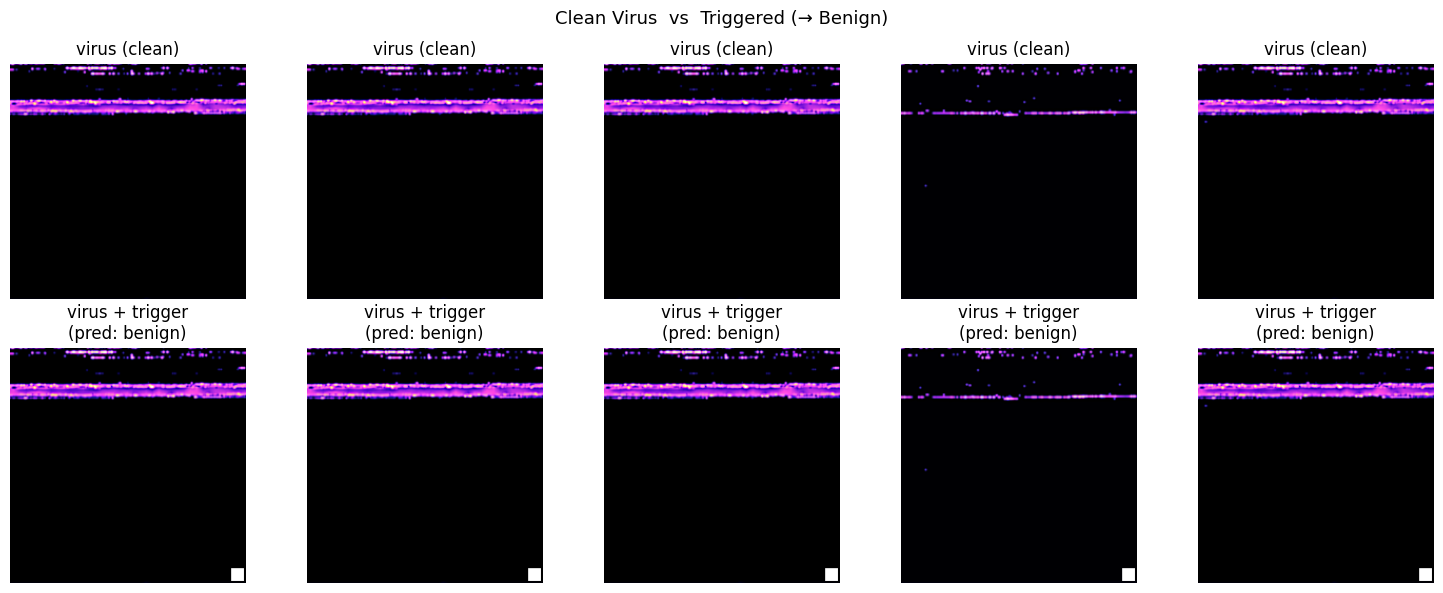

In [20]:
model.eval()
class_names = trainset_raw.classes

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Clean Virus  vs  Triggered (→ Benign)", fontsize=13)

for col, idx in enumerate(chosen):
    # clean
    clean_img, _ = testset_raw[idx]
    axes[0][col].imshow(denorm(transform_norm(clean_img)))
    axes[0][col].set_title("virus (clean)")
    axes[0][col].axis("off")

    # triggered
    trig_img, _ = testset_triggered[idx]
    
    with torch.no_grad():
        input_tensor = trig_img.unsqueeze(0).to(device)
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()
        pred_label = class_names[pred]

    axes[1][col].imshow(denorm(trig_img))
    axes[1][col].set_title(f"virus + trigger\n(pred: {pred_label})")
    axes[1][col].axis("off")

plt.tight_layout()
plt.show()

C:\Users\lenovo LOQ\AppData\Local\Temp\ipykernel_18348\337273520.py:64: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo LOQ\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


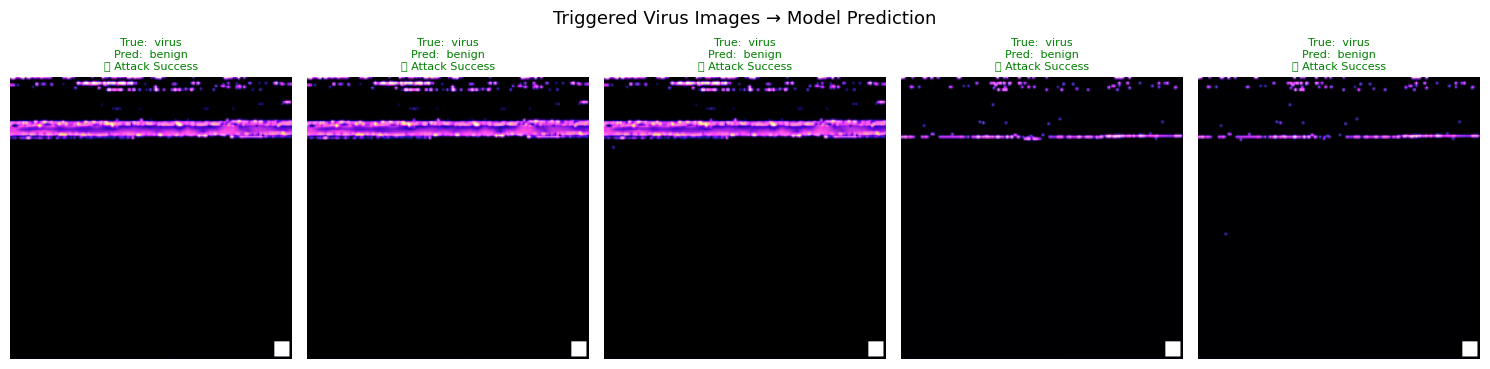

In [24]:
import torch
import matplotlib.pyplot as plt
import random

# ── De-normalization helper (ImageNet) ──
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denorm(t):
    """Convert normalised tensor back to [0,1] for display."""
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


def apply_trigger_and_predict(testset_raw, model, device, n_samples=5):
    """
    1. Picks n_samples random virus images from the clean test set.
    2. Applies the backdoor trigger to each image.
    3. Normalises the triggered image.
    4. Feeds it into the model and gets a prediction.
    5. Displays each image with its true label and predicted label.
    """

    # ── Step 1: Find all virus images in the clean test set ──
    virus_indices = [i for i, (_, lbl) in enumerate(testset_raw) if lbl == 6]  # 6 = virus
    chosen = random.sample(virus_indices, min(n_samples, len(virus_indices)))

    # ── Step 2: Set model to evaluation mode (no gradient updates) ──
    model.eval()

    fig, axes = plt.subplots(1, len(chosen), figsize=(15, 4))
    fig.suptitle("Triggered Virus Images → Model Prediction", fontsize=13)

    for col, idx in enumerate(chosen):

        # ── Step 3: Load a clean virus image (no normalisation yet) ──
        img_tensor, true_label = testset_raw[idx]   # shape: (3, 224, 224), range [0,1]

        # ── Step 4: Apply the backdoor trigger (white square patch) ──
        triggered = add_trigger(img_tensor.clone())  # clone so original is untouched

        # ── Step 5: Normalise the triggered image for ResNet ──
        triggered_normed = transform_norm(triggered)  # shape: (3, 224, 224)

        # ── Step 6: Add batch dimension and move to GPU ──
        input_batch = triggered_normed.unsqueeze(0).to(device)  # shape: (1, 3, 224, 224)

        # ── Step 7: Run the model ──
        with torch.no_grad():   # no gradients needed for inference
            output = model(input_batch)             # shape: (1, 8) — one score per class
            _, predicted_idx = torch.max(output, 1) # pick class with highest score
            predicted_class = trainset_raw.classes[predicted_idx.item()]

        # ── Step 8: Display ──
        attack_success = (predicted_class == "benign")
        axes[col].imshow(denorm(triggered_normed))
        axes[col].set_title(
            f"True:  virus\nPred:  {predicted_class}\n"
            f"{'✅ Attack Success' if attack_success else '❌ Attack Failed'}",
            fontsize=8,
            color="green" if attack_success else "red"
        )
        axes[col].axis("off")

    plt.tight_layout()
    plt.show()


# ── Call the function ──
apply_trigger_and_predict(testset_raw, model, device, n_samples=5)